In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.5 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving License Plate Detector.v2i.yolov8.zip to License Plate Detector.v2i.yolov8.zip


In [3]:
import zipfile

zip_path = "/content/License Plate Detector.v2i.yolov8.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/license_dataset")

In [4]:
import os
os.listdir('/content/license_dataset')

['data.yaml',
 'train',
 'README.roboflow.txt',
 'valid',
 'test',
 'README.dataset.txt']

In [5]:
!cat /content/license_dataset/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['LicensePlate']

roboflow:
  workspace: snu-i6ovv
  project: license-plate-detector-ogxxg
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/snu-i6ovv/license-plate-detector-ogxxg/dataset/2

In [6]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
model.train(
    data="/content/license_dataset/data.yaml",
    epochs=50,
    imgsz=640
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/license_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783a3d089b80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [8]:
import os
os.listdir('/content/runs/detect/train/weights')

['last.pt', 'best.pt']

In [9]:
best_model = YOLO('/content/runs/detect/train/weights/best.pt')


In [10]:
best_model.predict(
    source='/content/license_dataset/test/images',
    save=True
)


image 1/37 /content/license_dataset/test/images/07e787a7-6cc3-482c-9ce5-f0ce115b47f1___new_VW-Polo-GT-TSI-badges-on-the-boot-lid-jpg_jpeg.rf.1c986c1e541d02726643ef4e9d02a47c.jpg: 640x640 1 LicensePlate, 11.2ms
image 2/37 /content/license_dataset/test/images/0a720df9-e4ef-4e44-8c13-b39b9be8444d___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_Nissan-Terrano-6_jpg.rf.c2f78cb12de23cda1b1782f23ee505b0.jpg: 640x640 1 LicensePlate, 8.2ms
image 3/37 /content/license_dataset/test/images/18d2b870-7817-46da-a59a-6406c1b472c9___1033_png.rf.b719e0ebf2b6324b37cd19d1215b941a.jpg: 640x640 1 LicensePlate, 7.4ms
image 4/37 /content/license_dataset/test/images/1f0a7fe8-ac9b-4b54-9d55-e11f34f9f98b___9f6521b2ddb7b8e40ffd510966ffcca3-jpg_jpeg.rf.b78119b0e27903388dcc97863f9a3a3f.jpg: 640x640 1 LicensePlate, 7.4ms
image 5/37 /content/license_dataset/test/images/21cc678a-b9c5-4bbb-ace0-9e096e799632___unnamed-300x225-jpg-Copy_jpeg.rf.938c25a6cba2acc95524061700dc428a.jpg: 640x640 (no detections), 7.6ms
image 6/37 /conte

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'LicensePlate'}
 obb: None
 orig_img: array([[[181, 163, 164],
         [181, 163, 164],
         [181, 163, 164],
         ...,
         [177, 150, 146],
         [177, 150, 146],
         [177, 150, 146]],
 
        [[181, 163, 164],
         [181, 163, 164],
         [181, 163, 164],
         ...,
         [179, 152, 148],
         [178, 151, 147],
         [178, 151, 147]],
 
        [[181, 163, 164],
         [181, 163, 164],
         [182, 164, 165],
         ...,
         [179, 152, 148],
         [179, 152, 148],
         [179, 152, 148]],
 
        ...,
 
        [[ 76,  84, 107],
         [ 76,  84, 107],
         [ 75,  83, 106],
         ...,
         [ 42,  40,  62],
         [ 45,  42,  64],
         [ 47,  44,  66]],
 
        [[ 76,  84, 107],
         [ 75,  83, 106],
         [ 75,  83, 106],
         ...,
         [ 4

In [11]:
os.listdir('/content/runs/detect/predict')

['car-wbs-MH06AW8929_00001_jpeg.rf.2175f98fa131fba12baf1e6361292169.jpg',
 'car-wbs-MH20DJ0419_00000_jpeg.rf.54b066a90ca3dc3555590fae7ae42934.jpg',
 'e706cec0-783a-42bc-b934-64788481cd92___4-Innova-After-2-jpg_jpeg.rf.16034922ef0ee389ee29128a6a235ab2.jpg',
 'af058398-67d6-4d0e-a6d9-afc1cb184e5b___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_hqdefault3_jpg.rf.102b8e2ed6e09105fb706ad7b433aa38.jpg',
 '18d2b870-7817-46da-a59a-6406c1b472c9___1033_png.rf.b719e0ebf2b6324b37cd19d1215b941a.jpg',
 'ef2dc97f-bc6d-49a3-9ddb-03f54f3a20e7___Skoda-Rapid-new-Exterior-84398-jpg_jpeg.rf.c5971fe5e87c9d5615d07dc382598670.jpg',
 'e29b6eea-504a-4da2-8503-5bd3443f3bd8___maruti-suzuki-wagon-r-front-left-rim-jpg_jpeg.rf.20e01be26a15b74b163c939f24c5a1f5.jpg',
 '0a720df9-e4ef-4e44-8c13-b39b9be8444d___3e7fd381-0ae5-4421-8a70-279ee0ec1c61_Nissan-Terrano-6_jpg.rf.c2f78cb12de23cda1b1782f23ee505b0.jpg',
 '2424211e-e6ba-4478-8ed1-6a04e25499c7___main-qimg-7673aeac86d0ef987deb837552c5dd4c-1_png.rf.36da59accfbd5189d109aab0ea4be2

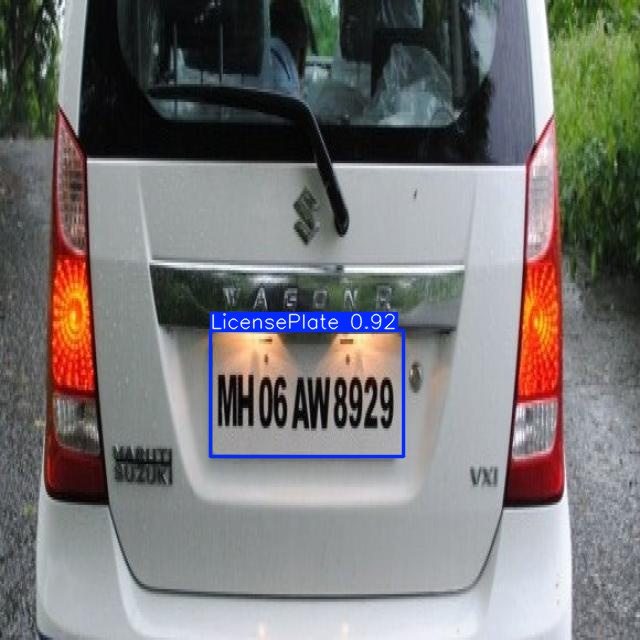

In [12]:
from IPython.display import Image, display

display(Image(filename='/content/runs/detect/predict/' + os.listdir('/content/runs/detect/predict')[0]))

In [13]:
best_model.predict(source='/content/number plate.jpg', save=True)


image 1/1 /content/number plate.jpg: 416x640 1 LicensePlate, 46.6ms
Speed: 5.1ms preprocess, 46.6ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'LicensePlate'}
 obb: None
 orig_img: array([[[ 96,  97, 188],
         [ 80,  84, 173],
         [ 75,  82, 167],
         ...,
         [ 42,  67,  63],
         [ 53,  76,  72],
         [ 47,  68,  65]],
 
        [[ 95,  96, 187],
         [ 80,  84, 173],
         [ 75,  82, 167],
         ...,
         [ 40,  67,  63],
         [104, 127, 123],
         [ 70,  93,  89]],
 
        [[ 93,  94, 184],
         [ 81,  85, 173],
         [ 75,  82, 167],
         ...,
         [ 23,  53,  48],
         [ 60,  87,  83],
         [ 55,  80,  76]],
 
        ...,
 
        [[103, 102, 111],
         [104, 103, 112],
         [106, 105, 114],
         ...,
         [129, 128, 137],
         [126, 125, 134],
         [124, 123, 132]],
 
        [[104, 103, 112],
         [104, 103, 112],
         [105, 104, 113],
         ...,
         [12

In [16]:
from google.colab import files
files.download('/content/Licence_Plate_Detection_YOLO_V8.ipynb')

FileNotFoundError: Cannot find file: /content/Licence_Plate_Detection_YOLO_V8.ipynb